# Optical pumping experiment

This notebook encompasses all of the data analysis for the PHYS 409 Optical pumping experiment.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os

In [45]:
# Converting the sweep values to b field values:
def add_magnetic_field(filename, timeconst):
    ItB = (0.6*10e-4)#Teslas
    df = pd.read_csv(filename, skiprows=2, usecols=[0, 1, 2], names=["Sequence", "CH1", "CH2"])
    df["Bfield"] = (df["CH1"]*ItB)/10
    df["CH2norm"] = (df["CH2"] - min(df["CH2"]))/(max(df["CH2"])-min(df["CH2"]))
    df["time"] = df["Sequence"]*timeconst
    filename, ext = os.path.splitext(filename)
    new_filename = f"{filename}_B{ext}"
    df.to_csv(new_filename, index=False)
    print("New file:",new_filename) 
    return df

df_25 = add_magnetic_field("linear_zeeman_data/NewFile25kHz.csv",5.000000e-03)
df_50 = add_magnetic_field("linear_zeeman_data/NewFile50kHz.csv",5.000000e-03)
df_75 = add_magnetic_field("linear_zeeman_data/NewFile75kHz.csv",5.000000e-03)
df_100 = add_magnetic_field("linear_zeeman_data/NewFile100kHz.csv",5.000000e-03)
df_125 = add_magnetic_field("linear_zeeman_data/NewFile125kHz.csv",5.000000e-03)
df_150 = add_magnetic_field("linear_zeeman_data/NewFile150kHz.csv",5.000000e-03)
df_175 = add_magnetic_field("linear_zeeman_data/NewFile175kHz.csv",5.000000e-03)
df_195 = add_magnetic_field("linear_zeeman_data/NewFile195kHz.csv",5.000000e-03)

New file: linear_zeeman_data/NewFile25kHz_B.csv
New file: linear_zeeman_data/NewFile50kHz_B.csv
New file: linear_zeeman_data/NewFile75kHz_B.csv
New file: linear_zeeman_data/NewFile100kHz_B.csv
New file: linear_zeeman_data/NewFile125kHz_B.csv
New file: linear_zeeman_data/NewFile150kHz_B.csv
New file: linear_zeeman_data/NewFile175kHz_B.csv
New file: linear_zeeman_data/NewFile195kHz_B.csv


### Lorentzian fit of the data:

$$f(x;A,x_0,\gamma) = A\cdot\frac{\gamma^2}{\gamma^2+(x-x_0)^2}$$

Specific heat capacity is analogous to your trainability coefficient. You want the specific heat capacity to be as low as possible for quick change of temperature in solids, similarly you want high trainability for weights. inversely related.

$$T_b \propto \frac{1}{C}$$


Solomonoff induction is actually stupid as fuck bruah. it's just an induction process that takes you from arbitrarily deciding the truth/ or arbitrary delibartion of the truth of any matter to something more justifiable and realistic. Solomonoff induction is basically bayesian statistics, coupled with hypothesis testing (perhaps a close link to the scientific method).  

In [ ]:
def lorentzian(x,ampl,center,hwhm,y0):
    return y0+(ampl*((hwhm**2)/(hwhm**2+(x-center)**2)))

In [49]:
def triple_lorentzian(x, y0, a1, c1, w1, a2, c2, w2, a3, c3, w3):
    L1 = a1 / (1 + ((x - c1) / w1)**2)
    L2 = a2 / (1 + ((x - c2) / w2)**2)
    L3 = a3 / (1 + ((x - c3) / w3)**2)
    return y0 + L1 + L2 + L3

In [67]:
def fit_lorentzian(p0,df):
    x_data,y_data = df["time"],df["CH2norm"]
    popt, pcov = curve_fit(triple_lorentzian,x_data,y_data,p0=p0)
    perr = np.sqrt(np.diag(pcov))
    print(f"Lorentzian peak 1:{popt[2]}±{perr[2]}")
    print(f"Lorentzian peak 2:{popt[5]}±{perr[5]}")
    print(f"Lorentzian peak 3:{popt[8]}±{perr[8]}")
    plt.plot(x_data, y_data, label='Data')
    plt.plot(x_data, triple_lorentzian(x_data, *popt), 'r-', label='Fitted Lorentzian')
    plt.legend()
    plt.show()
    return popt,perr

Lorentzian peak 1:2.0297152655954545±0.0006088111825396967
Lorentzian peak 2:2.5016267310765516±0.0007916638282646864
Lorentzian peak 3:1.3957372317429197±0.023824022018208258


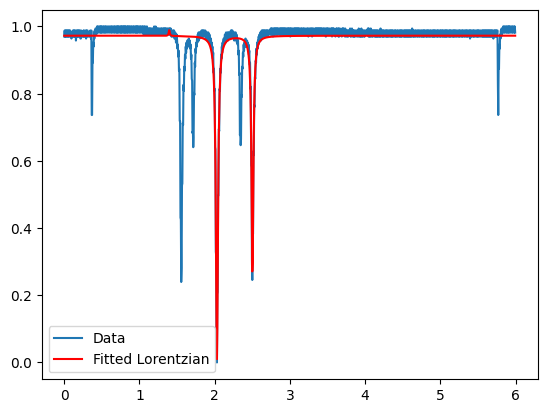

In [72]:
p0_guess = [1.0,-1.0,2.025,0.018,-0.75,2.5,0.023,-0.5,1.5,0.022]
popt,perr = fit_lorentzian(p0_guess,df_25)

Lorentzian peak 1:2.1808869100480623±0.0014885402665907007
Lorentzian peak 2:2.987260930290667±0.008799021105469143
Lorentzian peak 3:2.489484193224263±0.061670306127795206


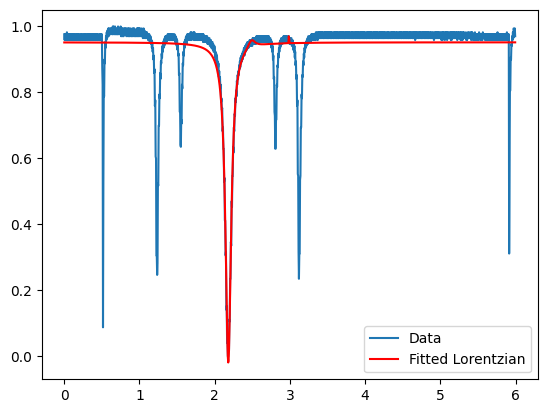

In [74]:
p0_guess = [1.0,-1.0,2.025,0.018,-0.75,3.0,0.023,-0.5,2.5,0.022]
popt,perr = fit_lorentzian(p0_guess,df_50)

Lorentzian peak 1:2.1670666825283225±0.0018636802148222953
Lorentzian peak 2:2.6630431464028907±0.0808434316041652
Lorentzian peak 3:3.4572798751090317±0.006933717114232027


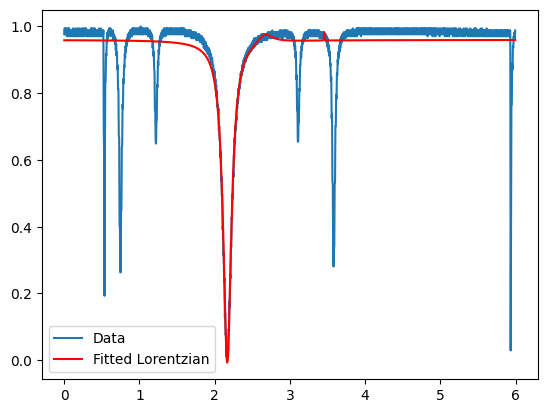

In [ ]:
p0_guess = [1.0,-1.0,2.025,0.018,-0.5,3.0,0.023,-0.75,3.5,0.022]
popt,perr = fit_lorentzian(p0_guess,df_75)